In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")

In [3]:
import os

print(os.listdir(path))
print("\n")
print(os.listdir(path + '/train-images-idx3-ubyte/'))

['t10k-images-idx3-ubyte', 't10k-images.idx3-ubyte', 't10k-labels-idx1-ubyte', 't10k-labels.idx1-ubyte', 'train-images-idx3-ubyte', 'train-images.idx3-ubyte', 'train-labels-idx1-ubyte', 'train-labels.idx1-ubyte']


['train-images-idx3-ubyte']


In [4]:
import numpy as np

def load_images(path):
    with open(path, 'rb') as f:
        magic, n, rows, cols = np.frombuffer(f.read(16), dtype='>i4')
        images = np.frombuffer(f.read(), dtype=np.uint8)
    return images.reshape(n, rows, cols)

def load_labels(path):
    with open(path, 'rb') as f:
        magic, n = np.frombuffer(f.read(8), dtype='>i4')
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

X_train = load_images(path + '/train-images-idx3-ubyte/train-images-idx3-ubyte')
y_train = load_labels(path + '/train-labels-idx1-ubyte/train-labels-idx1-ubyte')
X_test  = load_images(path + '/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
y_test  = load_labels(path + '/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

In [5]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
def process_x(X, fit):
    N, H, W = X.shape
    X_flat = X.reshape(N, H * W)
    if fit:
        scaler.fit(X_flat)
    return scaler.transform(X_flat)

X_train = process_x(X_train, True)
X_test = process_x(X_test, False)

In [6]:
# Show a few
from matplotlib import pyplot as plt
from ipywidgets import interact, IntSlider

interact(
    lambda i: plt.imshow(X_train[i].reshape(28, 28), cmap="gray"), i=IntSlider(min=0, max=len(y_train) - 1)
)

interactive(children=(IntSlider(value=0, description='i', max=59999), Output()), _dom_classes=('widget-interac…

<function __main__.<lambda>(i)>

In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def make_loader(X, y, batch_size=256, shuffle=False):
    dataset = TensorDataset(
        torch.from_numpy(X.astype(np.float32)),
        torch.from_numpy(y),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=4)

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader = make_loader(X_test, y_test)

/tmp/ipykernel_15559/1608567004.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.from_numpy(y),


In [7]:
from SparseCAE import SparseCAE
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

In [48]:
model = SparseCAE(
    input_dim=28 * 28,
    latent_dim=4,
    hidden_dims=[256],
    lambda_sparse=1e-2,
    lambda_cae=1e-3,
    lr=1e-3,
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    callbacks=[
        EarlyStopping(monitor="val/loss", patience=10),
        ModelCheckpoint(monitor="val/loss", filename="best", mode="min")
    ],
)
trainer.fit(model, train_loader, test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | encoder | Sequential | 201 K  | train | 0    
1 | decoder | Sequential | 202 K  | train | 0    
-------------------------------------------------------
404 K     Trainable params
0         Non-trainable params
404 K     Total params
1.619     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [8]:
model = SparseCAE.load_from_checkpoint("./model_checkpoint.ckpt")
model.cpu() # For easier inference for visualizing it

SparseCAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=4, bias=True)
    (3): ReLU()
    (4): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

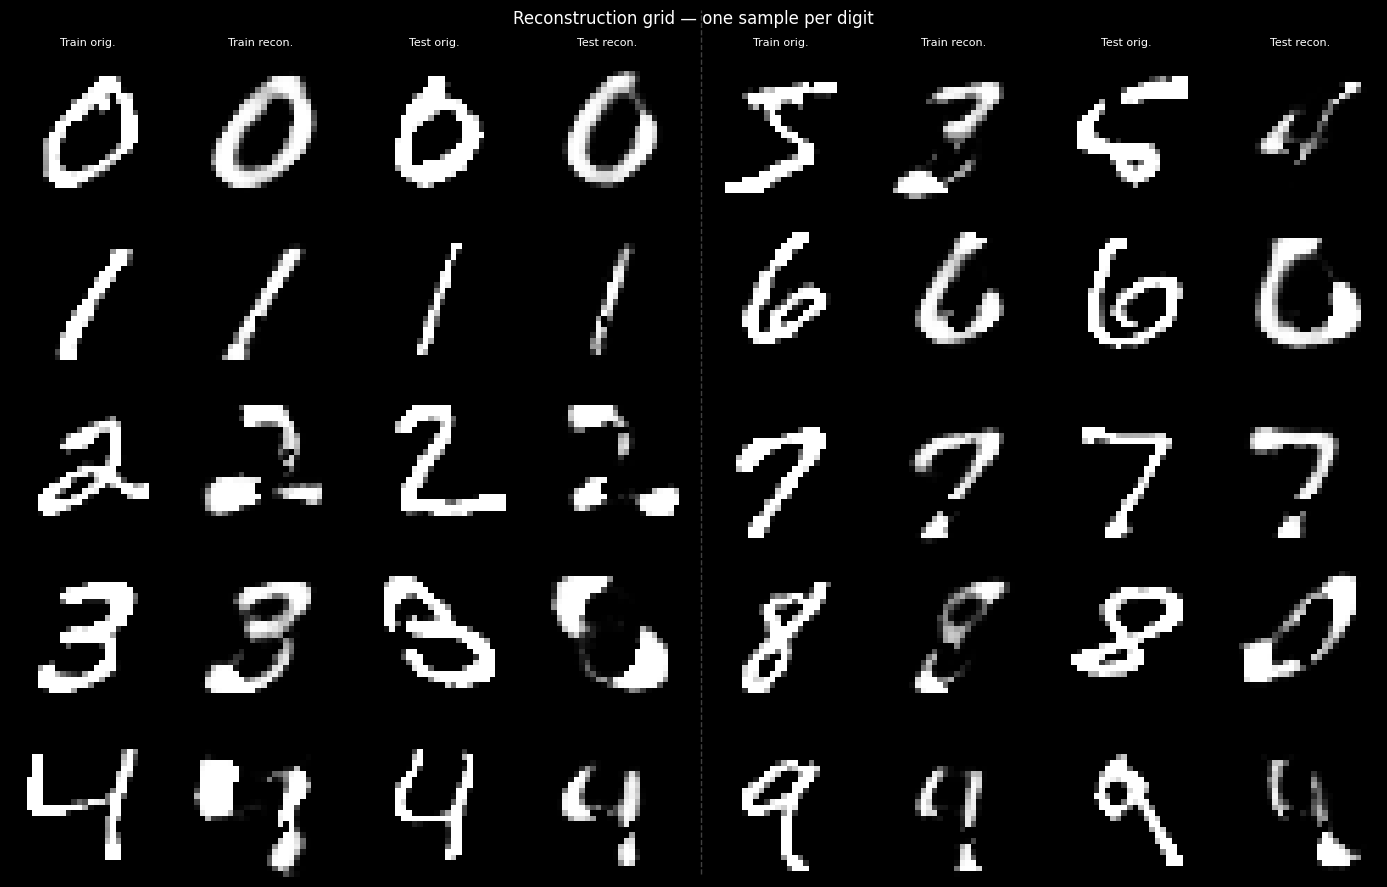

In [11]:
@torch.no_grad()
def plot_reconstruction_grid():
    # 5 rows x 8 cols: left half = digits 0-4, right half = digits 5-9
    fig, axes = plt.subplots(5, 8, figsize=(14, 9))
    col_labels = ["Train orig.", "Train recon.", "Test orig.", "Test recon."]

    for i, digit in enumerate(range(10)):
        row = i % 5          # 0-4 for both halves
        col_offset = (i // 5) * 4  # 0 for digits 0-4, 4 for digits 5-9

        # Get first sample of each digit from train and test sets
        idx_train = np.where(y_train == digit)[0][0]
        idx_test  = np.where(y_test  == digit)[0][0]

        x_tr = torch.from_numpy(X_train[idx_train:idx_train+1].astype(np.float32))
        x_te = torch.from_numpy(X_test [idx_test :idx_test +1].astype(np.float32))

        recon_tr = model(x_tr).numpy().reshape(28, 28)
        recon_te = model(x_te).numpy().reshape(28, 28)

        imgs = [
            X_train[idx_train].reshape(28, 28),
            recon_tr,
            X_test[idx_test].reshape(28, 28),
            recon_te,
        ]

        for col, img in enumerate(imgs):
            ax = axes[row, col_offset + col]
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            # Column headers on row 0 for each half
            if row == 0:
                ax.set_title(col_labels[col], fontsize=8)
        # Digit label on the first column of each half
        axes[row, col_offset].set_ylabel(f"Digit {digit}", fontsize=9,
                                          rotation=0, labelpad=40, va="center")

    # Add a vertical separator between the two halves
    line = plt.Line2D([0.505, 0.505], [0.02, 0.98],
                      transform=fig.transFigure, color="gray",
                      linewidth=1, linestyle="--", alpha=0.5)
    fig.add_artist(line)

    plt.suptitle("Reconstruction grid — one sample per digit", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_reconstruction_grid()

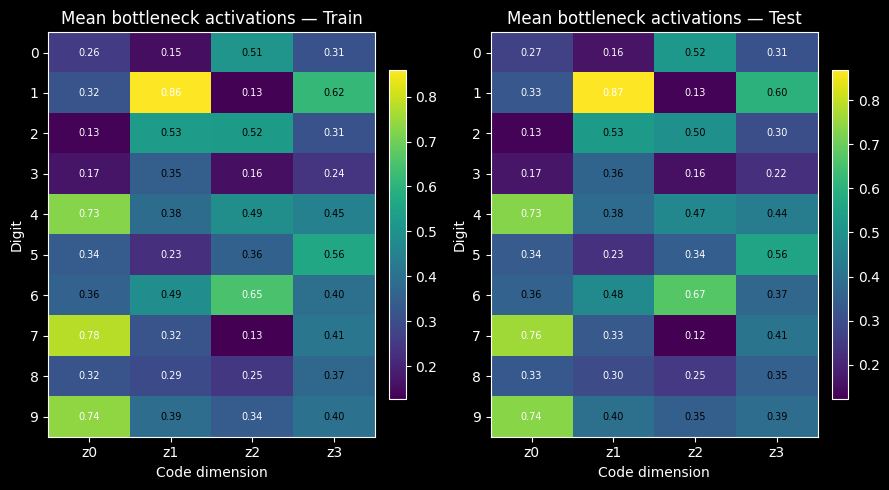

In [12]:
@torch.no_grad()
def plot_code_heatmap():
    # Encode a full dataset split down to the bottleneck representation
    def encode(X):
        x = torch.from_numpy(X.astype(np.float32))
        return model.encoder(x).numpy()  # shape (N, 4)

    codes_train = encode(X_train)  # (N_train, 4)
    codes_test  = encode(X_test)   # (N_test,  4)

    # Compute mean activation per digit across both splits
    mean_train = np.array([codes_train[y_train == d].mean(axis=0) for d in range(10)])
    mean_test  = np.array([codes_test [y_test  == d].mean(axis=0) for d in range(10)])

    fig, axes = plt.subplots(1, 2, figsize=(9, 5))

    for ax, data, split in zip(axes, [mean_train, mean_test], ["Train", "Test"]):
        im = ax.imshow(data, aspect="auto")
        ax.set_xticks(range(4))
        ax.set_xticklabels([f"z{i}" for i in range(4)])
        ax.set_yticks(range(10))
        ax.set_yticklabels([str(d) for d in range(10)])
        ax.set_xlabel("Code dimension")
        ax.set_ylabel("Digit")
        ax.set_title(f"Mean bottleneck activations — {split}")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Annotate each cell with its value
        vmin, vmax = data.min(), data.max()
        for i in range(10):
            for j in range(4):
                normalized = (data[i, j] - vmin) / (vmax - vmin + 1e-8)
                color = "black" if 0.3 < normalized < 0.7 else "white"
                ax.text(j, i, f"{data[i, j]:.2f}",
                        ha="center", va="center", fontsize=7, color=color)

    plt.tight_layout()
    plt.show()

plot_code_heatmap()

In [13]:
from ipywidgets import FloatSlider, HBox, VBox, Output
import ipywidgets as widgets

out = Output()
sliders = [FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description=f"z[{i}]") for i in range(4)]

def update(*args):
    z = torch.tensor([[s.value for s in sliders]], dtype=torch.float32)
    with torch.no_grad():
        x_hat = model.decoder(z).numpy().reshape(28, 28)
    with out:
        out.clear_output(wait=True)
        plt.figure(figsize=(3, 3))
        plt.imshow(x_hat, cmap="gray")
        plt.title(f"z = {[round(s.value, 2) for s in sliders]}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

for s in sliders:
    s.observe(update, names="value")

update()
display(VBox([*sliders, out]))

In [ ]:
# Generate reconstruction grid